## References

[1] V. Achhatrara, “Missing Values Pima Indians Diabetes Data,” Kaggle, [Online]. Available: https://www.kaggle.com/datasets/vishvaachhatrara/missing-values-pima-indians-diabetes-data.

# 1.Load the dataset

In [1]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

os.makedirs("plots", exist_ok=True)

1.Load the dataset into a pandas DataFrame using pd.read_csv() (or equivalent).<br>Print the first five rows, the column data types (.dtypes), and the DataFrame shape.

In [3]:

#path = "C:\\Users\\vijay\\OneDrive\\Documents\\Diabetes_Prediction\\archive.zip"
#with zipfile.ZipFile(path, "r") as zip_ref:
#    zip_ref.extractall("C:\\Users\\vijay\\OneDrive\\Documents\\Diabetes_Prediction")
#print("Zip file extracted successfully.")

In [4]:
#Load dataset into a pandas DataFrame:

df = pd.read_csv("C:\\Users\\vijay\\OneDrive\\Documents\\Diabetes_Prediction\\pima_Missing_values.csv")

#Print the first five rows of the DataFrame
print(df.head())

  NoOfPregency PlasmaGlucoseCon BloodPressure SkinFoldThickness Insuline  \
0           10              108            66            <null>        0   
1            7              107            74                 0        0   
2            0              179            90                27   <null>   
3           10              125            70                26   <null>   
4           10           <null>        <null>                 0        0   

      BMI DiabetesPedigree Age            Class  
0    32.4            0.272  42  tested_positive  
1    29.6            0.254  31  tested_positive  
2  <null>            0.686  23  tested_positive  
3    31.1            0.205  41  tested_positive  
4      38            0.537  34  tested_positive  


In [5]:
#Print the column dtypes of the DataFrame
print(df.dtypes)


NoOfPregency         object
PlasmaGlucoseCon     object
BloodPressure        object
SkinFoldThickness    object
Insuline             object
BMI                  object
DiabetesPedigree     object
Age                  object
Class                object
dtype: object


In [6]:
#Print the shape of the DataFrame
print(df.shape)

(690, 9)


# 4.Data Type Correction

Before handling missing values, it is important to perform type conversion because the variables 'PlasmaGlucoseCon', 'BloodPressure', 'SkinFoldThickness', 'Insuline', 'BMI', and 'Age' cannot logically have a value of zero. Therefore, these columns should be converted to the appropriate numeric (integer) data type so that zero values can be identified, treated as missing values, and imputed accordingly.

In [7]:
df.dtypes

NoOfPregency         object
PlasmaGlucoseCon     object
BloodPressure        object
SkinFoldThickness    object
Insuline             object
BMI                  object
DiabetesPedigree     object
Age                  object
Class                object
dtype: object

In [8]:
memory_before = df.memory_usage(deep=True).sum()
cols = ['NoOfPregency','PlasmaGlucoseCon', 'BloodPressure', 'SkinFoldThickness',
        'Insuline', 'BMI', 'DiabetesPedigree', 'Age']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Class'] = df['Class'].astype('category')


print(df.dtypes)
print(df['Class'].cat.categories)
print("\nMemory usage before conversion:", memory_before)
print("Memory usage after conversion:", df.memory_usage(deep=True).sum())


NoOfPregency          float64
PlasmaGlucoseCon      float64
BloodPressure         float64
SkinFoldThickness     float64
Insuline              float64
BMI                   float64
DiabetesPedigree      float64
Age                   float64
Class                category
dtype: object
Index(['tested_negative', 'tested_positive'], dtype='object')

Memory usage before conversion: 330466
Memory usage after conversion: 45218


In [9]:
# Before imputation
insuline_mean_before = round(df['Insuline'].mean(), 2)
insuline_median_before = round(df['Insuline'].median(), 2)
diabetespedigree_mean_before = round(df['DiabetesPedigree'].mean(), 4)
diabetespedigree_median_before = round(df['DiabetesPedigree'].median(), 4)
print("Strategy comparison Before Imputation applied")
print(f"\t Insulin \t DiabetesPedigree \n Mean \t {insuline_mean_before}\t\t {diabetespedigree_mean_before} ")
print(f"Median \t {insuline_median_before} \t\t {diabetespedigree_median_before}")

Strategy comparison Before Imputation applied
	 Insulin 	 DiabetesPedigree 
 Mean 	 83.71		 0.4682 
Median 	 39.0 		 0.371


# 2. Null value analysis

Null value analysis: Compute the count and percentage of missing values in every column using df.isnull().sum() and (df.isnull().sum() / df.shape[0]) * 100. Report which columns exceed a 20% null rate.<br>For columns below 20% nulls, fill numeric columns with the column median using fillna(df[col].median()). <br>Justify in the README why you chose the median rather than the mean.



In [10]:
print(df.isnull().sum())

NoOfPregency         66
PlasmaGlucoseCon     69
BloodPressure        78
SkinFoldThickness    65
Insuline             72
BMI                  66
DiabetesPedigree     75
Age                  61
Class                 0
dtype: int64


In [11]:
(df.isnull().sum() / df.shape[0]) * 100

NoOfPregency          9.565217
PlasmaGlucoseCon     10.000000
BloodPressure        11.304348
SkinFoldThickness     9.420290
Insuline             10.434783
BMI                   9.565217
DiabetesPedigree     10.869565
Age                   8.840580
Class                 0.000000
dtype: float64

In [12]:
cols = [
    'NoOfPregency',
    'PlasmaGlucoseCon',
    'BloodPressure',
    'SkinFoldThickness',
    'Insuline',
    'BMI',
    'DiabetesPedigree',
    'Age'
]

for col in cols:
    df[col].fillna(df[col].median())
print(df.isnull().sum())

NoOfPregency         66
PlasmaGlucoseCon     69
BloodPressure        78
SkinFoldThickness    65
Insuline             72
BMI                  66
DiabetesPedigree     75
Age                  61
Class                 0
dtype: int64


# Handling Zero Values

In [13]:
(df == 0).sum()
#PlasmaGlucoseConcentraton, BloodPressure, SkinFoldThickness, Insulin BMI and Age cannot be zero. 
# So we will replace the zero values with the median of the respective columns.


NoOfPregency          95
PlasmaGlucoseCon       4
BloodPressure         30
SkinFoldThickness    186
Insuline             297
BMI                    9
DiabetesPedigree       0
Age                    0
Class                  0
dtype: int64

In [14]:
cols = [
    'PlasmaGlucoseCon',
    'BloodPressure',
    'SkinFoldThickness',
    'Insuline',
    'BMI',
    'DiabetesPedigree',
    'Age'
]
df[cols] = df[cols].replace(0, np.nan)

print(df.isnull().sum())


NoOfPregency          66
PlasmaGlucoseCon      73
BloodPressure        108
SkinFoldThickness    251
Insuline             369
BMI                   75
DiabetesPedigree      75
Age                   61
Class                  0
dtype: int64


In [15]:
df[cols] = df[cols].fillna(df[cols].median())
print(df.isnull().sum())

NoOfPregency         66
PlasmaGlucoseCon      0
BloodPressure         0
SkinFoldThickness     0
Insuline              0
BMI                   0
DiabetesPedigree      0
Age                   0
Class                 0
dtype: int64


# 3.Duplicate detection and removal

Use df.duplicated().sum() to count duplicates. Remove them with df.drop_duplicates().<br>Report how many rows were removed and whether the removal changes any column's null percentage.

In [16]:
df.duplicated().sum()

np.int64(0)

Since there is no duplicate rows in this dataset, so unable to remove any duplicate rows!

# 5.Descriptive statistics and skewness

Call df.describe() on all numeric columns. For each numeric column, compute df[col].skew(). Identify and name the column with the highest absolute skewness. Explain in the README what positive vs negative skew means for that column's distribution and what consequence it has for imputing missing values with the mean.

In [17]:
df.describe()

,NoOfPregency,PlasmaGlucoseCon,BloodPressure,SkinFoldThickness,Insuline,BMI,DiabetesPedigree,Age
count,624.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000
mean,3.782051,120.905797,72.328986,28.972464,144.494203,32.316087,0.457609,32.504348
std,3.353530,28.646002,11.129031,8.439873,84.872537,6.624248,0.314625,11.138428
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,101.000000,66.000000,26.000000,130.000000,27.800000,0.254000,24.000000
50%,3.000000,117.000000,72.000000,29.000000,130.000000,32.000000,0.371000,29.000000
75%,6.000000,136.000000,78.000000,32.000000,130.000000,35.700000,0.586000,38.000000
max,17.000000,199.000000,114.000000,99.000000,846.000000,67.100000,2.420000,72.000000


In [18]:
cols = [
    'NoOfPregency',
    'PlasmaGlucoseCon',
    'BloodPressure',
    'SkinFoldThickness',
    'Insuline',
    'BMI',
    'DiabetesPedigree',
    'Age'
]
for col in cols:
    print(f"Skewness of {col}: {round(df[col].skew(), 4)}")

skew_values = df[cols].skew()

most_skewed = skew_values.abs().idxmax()
print(f"\nMost skewed column \n{most_skewed} : {round(df[most_skewed].skew(),4)}")


Skewness of NoOfPregency: 0.8892
Skewness of PlasmaGlucoseCon: 0.6731
Skewness of BloodPressure: 0.0561
Skewness of SkinFoldThickness: 0.9854
Skewness of Insuline: 3.5761
Skewness of BMI: 0.7253
Skewness of DiabetesPedigree: 2.303
Skewness of Age: 1.2782

Most skewed column 
Insuline : 3.5761


# 6.Outlier detection with IQR

For at least two numeric columns, compute Q1 (df[col].quantile(0.25)), Q3 (df[col].quantile(0.75)), IQR = Q3 − Q1, lower bound = Q1 − 1.5 × IQR, and upper bound = Q3 + 1.5 × IQR. <br>Count the number of rows that fall outside these bounds.<br>Do not drop the outliers — instead, document them and state in the README whether you will cap them, retain them, or handle them differently in Part 2, and why.

In [19]:
q1_insulin = df['Insuline'].quantile(0.25)
print(f"Q1 of Insulin: {q1_insulin}")

q3_insulin = df['Insuline'].quantile(0.75)
print(f"Q3 of Insulin: {q3_insulin}")

iqr_insulin = q3_insulin - q1_insulin
print(f"IQR of Insulin: {iqr_insulin}")

lower_bound_insulin = q1_insulin - 1.5 * iqr_insulin
print(f"Lower bound of Insulin: {lower_bound_insulin}")

upper_bound_insulin = q3_insulin + 1.5 * iqr_insulin
print(f"Upper bound of Insulin: {upper_bound_insulin}")

outliers_insulin = df[(df['Insuline'] < lower_bound_insulin) | (df['Insuline'] > upper_bound_insulin)]

print(f"Number of outliers in Insulin: {outliers_insulin.shape[0]}")

Q1 of Insulin: 130.0
Q3 of Insulin: 130.0
IQR of Insulin: 0.0
Lower bound of Insulin: 130.0
Upper bound of Insulin: 130.0
Number of outliers in Insulin: 314


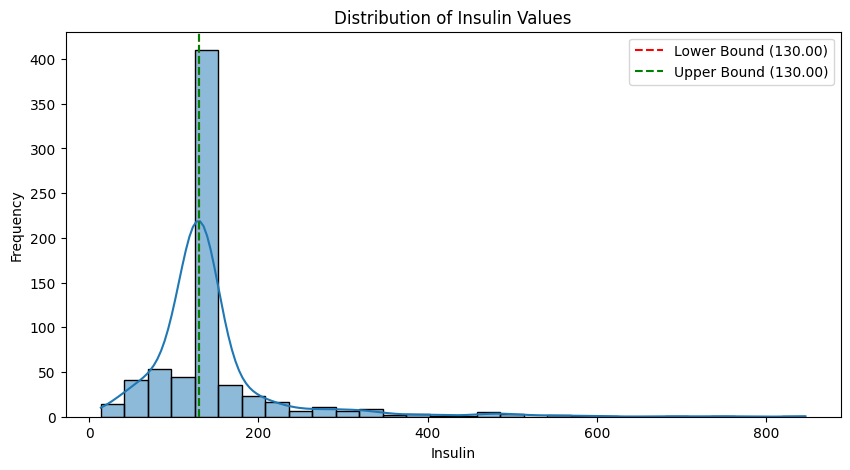

In [20]:

plt.figure(figsize=(10, 5))

sns.histplot(df['Insuline'], bins=30, kde=True)

plt.axvline(lower_bound_insulin, color='red', linestyle='--',
            label=f'Lower Bound ({lower_bound_insulin:.2f})')
plt.axvline(upper_bound_insulin, color='green', linestyle='--',
            label=f'Upper Bound ({upper_bound_insulin:.2f})')

plt.title('Distribution of Insulin Values')
plt.xlabel('Insulin')
plt.ylabel('Frequency')
plt.legend()

plt.savefig('plots/Distribution_of_Insulin_Values.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
q1_bmi = df['BMI'].quantile(0.25)
print(f"Q1 of BMI: {q1_bmi}")

q3_bmi = df['BMI'].quantile(0.75)
print(f"Q3 of BMI: {q3_bmi}")

iqr_bmi = q3_bmi - q1_bmi
print(f"IQR of BMI: {iqr_bmi}")

lower_bound_bmi = q1_bmi - 1.5 * iqr_bmi
print(f"Lower bound of BMI: {lower_bound_bmi}")

upper_bound_bmi = q3_bmi + 1.5 * iqr_bmi
print(f"Upper bound of BMI: {upper_bound_bmi}")

outliers_bmi = df[(df['BMI'] < lower_bound_bmi) | (df['BMI'] > upper_bound_bmi)]

print(f"Number of outliers in BMI: {outliers_bmi.shape[0]}")

Q1 of BMI: 27.8
Q3 of BMI: 35.7
IQR of BMI: 7.900000000000002
Lower bound of BMI: 15.949999999999998
Upper bound of BMI: 47.550000000000004
Number of outliers in BMI: 15


# 7.Visualizations

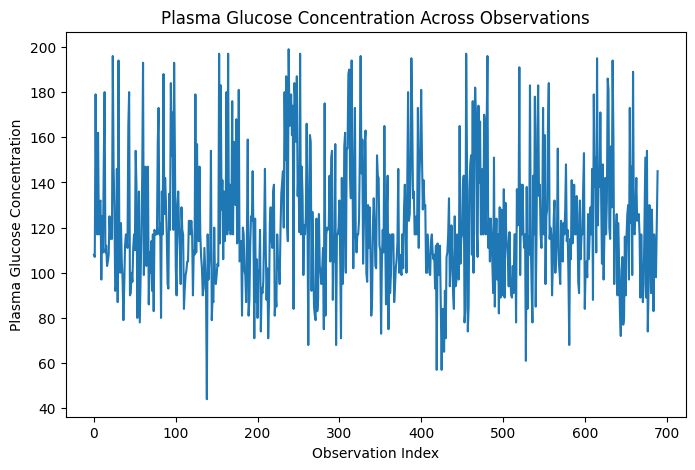

In [22]:
plt.figure(figsize=(8,5))
plt.plot(df.index, df['PlasmaGlucoseCon'])
plt.title('Plasma Glucose Concentration Across Observations')
plt.xlabel('Observation Index')
plt.ylabel('Plasma Glucose Concentration')
plt.savefig('plots/Plasma_Glucose_Concentration_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()


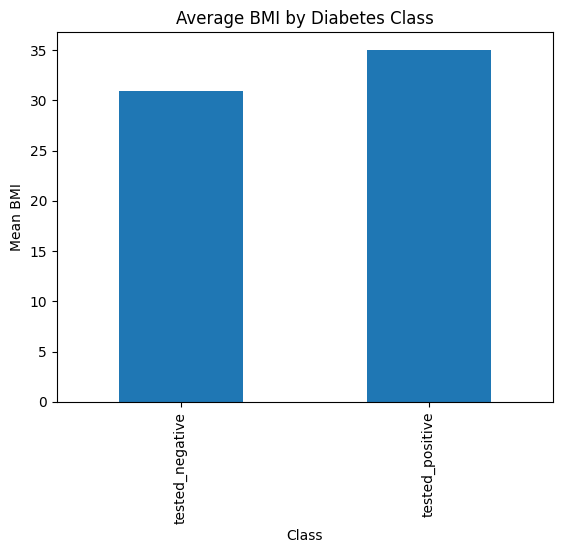

In [23]:
df.groupby('Class', observed = True)['BMI'].mean().plot.bar()

plt.title('Average BMI by Diabetes Class')
plt.xlabel('Class')
plt.ylabel('Mean BMI')
plt.savefig('plots/Average_BMI_by_Diabetes_Class_Barchart.png', dpi=300, bbox_inches='tight')
plt.show()


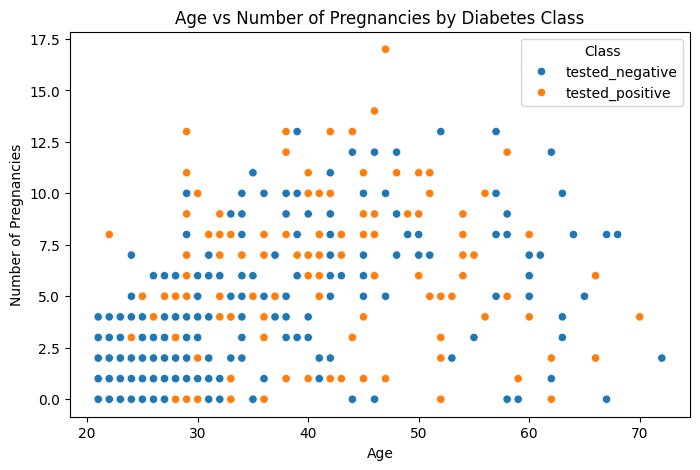

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Age',
    y='NoOfPregency',
    hue='Class'
)

plt.title('Age vs Number of Pregnancies by Diabetes Class')
plt.xlabel('Age')
plt.ylabel('Number of Pregnancies')
plt.savefig('plots/Scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

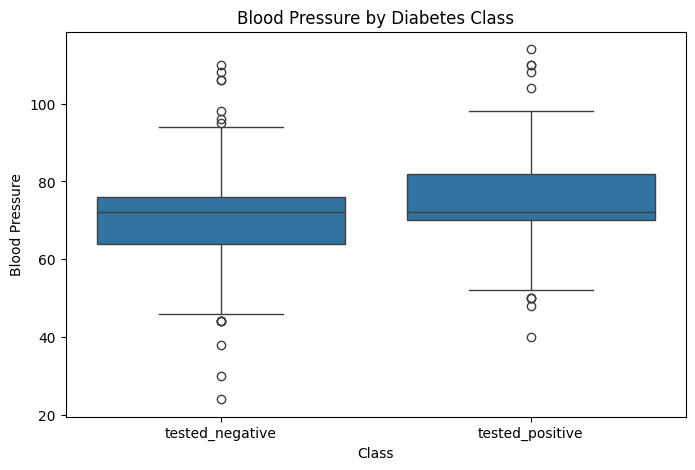

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Class',
    y='BloodPressure'
)

plt.title('Blood Pressure by Diabetes Class')
plt.xlabel('Class')
plt.ylabel('Blood Pressure')
plt.savefig('plots/Box_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# 8.Correlation heat map

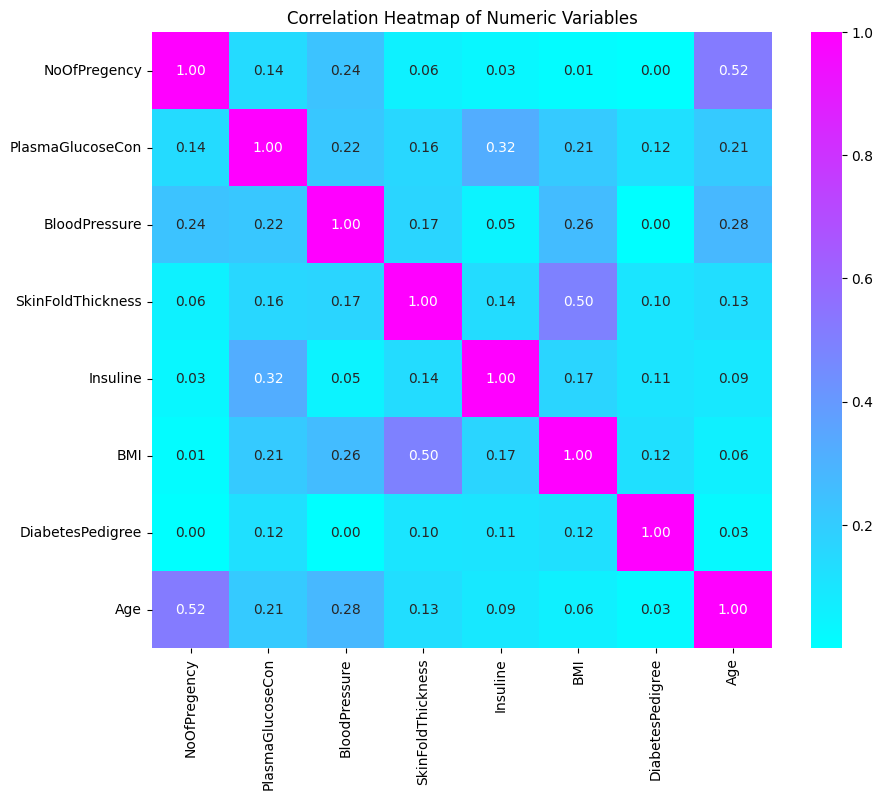

In [26]:
plt.figure(figsize=(10, 8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='cool',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numeric Variables')
plt.savefig('plots/corr_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


# 9.a.Imputation strategy comparison. 

In [27]:
print("Strategy comparison Before Imputation applied")
print(f"\t Insulin \t DiabetesPedigree \n Mean \t {insuline_mean_before}\t\t {diabetespedigree_mean_before} ")
print(f"Median \t {insuline_median_before} \t\t {diabetespedigree_median_before}")


Strategy comparison Before Imputation applied
	 Insulin 	 DiabetesPedigree 
 Mean 	 83.71		 0.4682 
Median 	 39.0 		 0.371


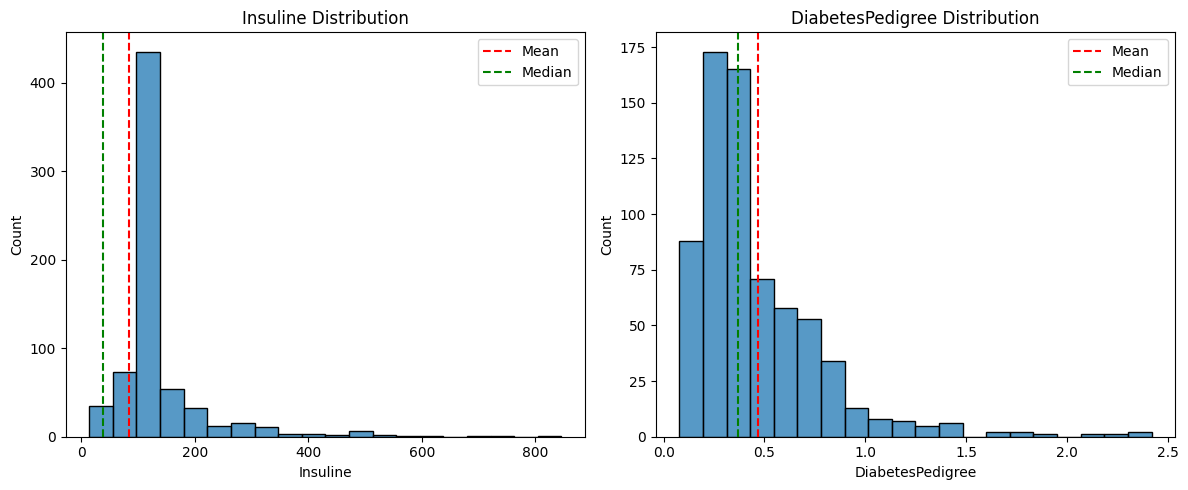

In [28]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['Insuline'], bins=20, ax=axes[0])
axes[0].axvline(insuline_mean_before, color='red', linestyle='--', label='Mean')
axes[0].axvline(insuline_median_before, color='green', linestyle='--', label='Median')
axes[0].set_title('Insuline Distribution')
axes[0].legend()

sns.histplot(df['DiabetesPedigree'], bins=20, ax=axes[1])
axes[1].axvline(diabetespedigree_mean_before, color='red', linestyle='--', label='Mean')
axes[1].axvline(diabetespedigree_median_before, color='green', linestyle='--', label='Median')
axes[1].set_title('DiabetesPedigree Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/Imputation_strategy_comparison_before.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
# Before imputation
insuline_mean_after = round(df['Insuline'].mean(), 2)
insuline_median_after = round(df['Insuline'].median(), 2)
diabetespedigree_mean_after = round(df['DiabetesPedigree'].mean(), 4)
diabetespedigree_median_after = round(df['DiabetesPedigree'].median(), 4)
print("Strategy comparison Before Imputation applied")
print(f"\t Insulin \t DiabetesPedigree \n Mean \t {insuline_mean_after}\t\t {diabetespedigree_mean_after} ")
print(f"Median \t {insuline_median_after} \t\t {diabetespedigree_median_after}")

Strategy comparison Before Imputation applied
	 Insulin 	 DiabetesPedigree 
 Mean 	 144.49		 0.4576 
Median 	 130.0 		 0.371


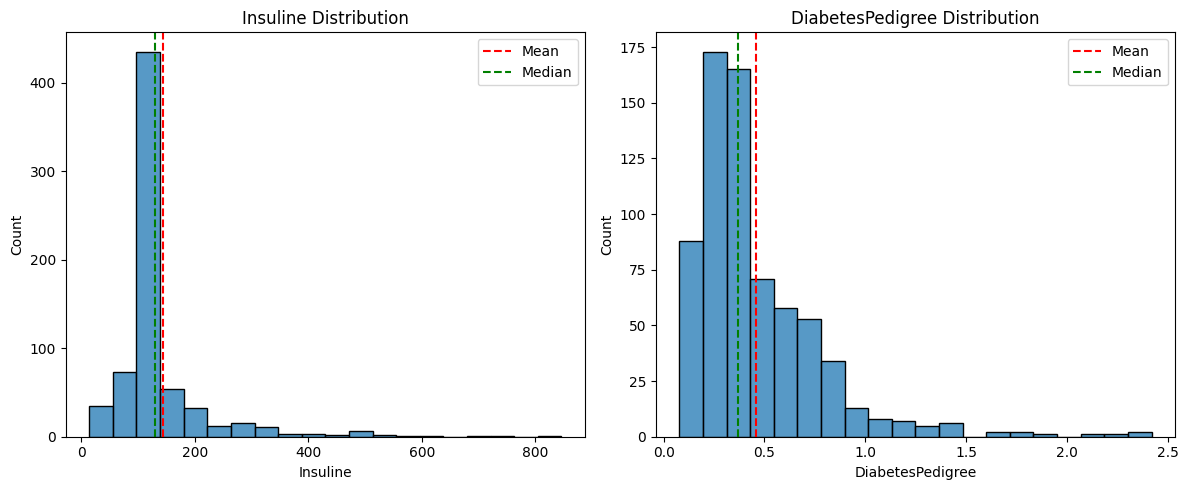

In [30]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['Insuline'], bins=20, ax=axes[0])
axes[0].axvline(insuline_mean_after, color='red', linestyle='--', label='Mean')
axes[0].axvline(insuline_median_after, color='green', linestyle='--', label='Median')
axes[0].set_title('Insuline Distribution')
axes[0].legend()

sns.histplot(df['DiabetesPedigree'], bins=20, ax=axes[1])
axes[1].axvline(diabetespedigree_mean_after, color='red', linestyle='--', label='Mean')
axes[1].axvline(diabetespedigree_median_after, color='green', linestyle='--', label='Median')
axes[1].set_title('DiabetesPedigree Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/Imputation_strategy_comparison_after.png', dpi=300, bbox_inches='tight')
plt.show()

# 9.b.Spearman rank correlation

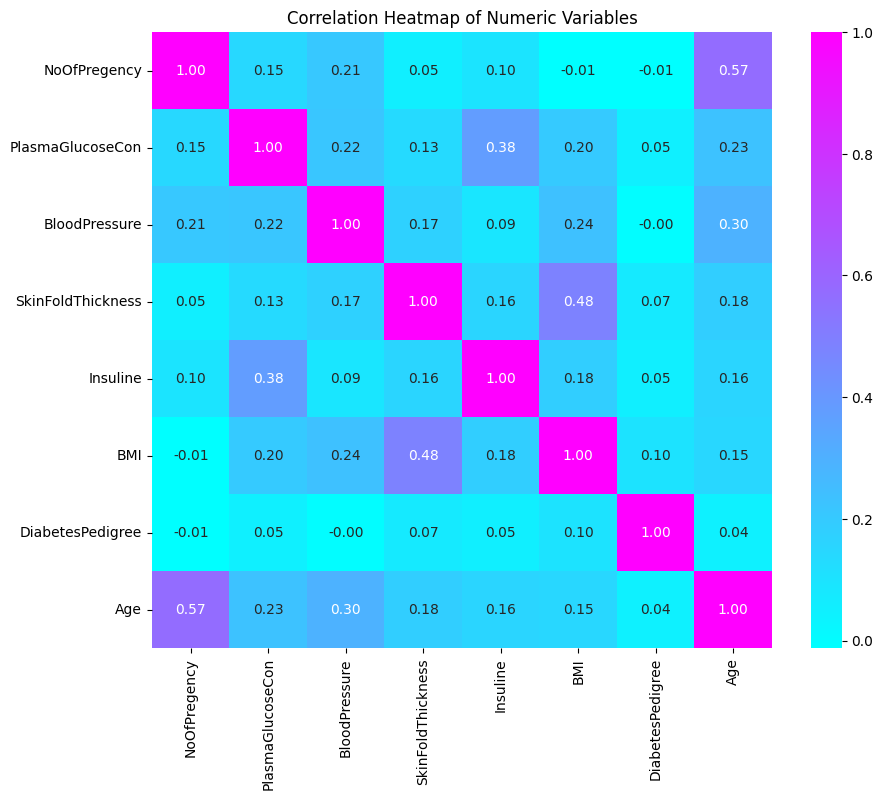

In [31]:
plt.figure(figsize=(10, 8))
spearman_corr_matrix = df.corr(numeric_only=True, method = 'spearman')

sns.heatmap(
    spearman_corr_matrix,
    annot=True,
    cmap='cool',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numeric Variables')
plt.savefig('plots/spearman_corr.png', dpi=300, bbox_inches='tight')
plt.show()


In [32]:
# Absolute difference
diff_matrix = abs(spearman_corr_matrix - corr_matrix)

# Remove diagonal
np.fill_diagonal(diff_matrix.values, np.nan)

# Convert matrix to pairwise table
difference_table = (
    diff_matrix.stack()
    .reset_index()
)

difference_table.columns = ['Feature_1', 'Feature_2', '|Spearman - Pearson|']

# Remove duplicate pairs
difference_table = difference_table[
    difference_table['Feature_1'] < difference_table['Feature_2']
]

difference_table = difference_table.sort_values(
    by='|Spearman - Pearson|',
    ascending=False
)



print("\nTop 5 Pairs\n",difference_table.head(5).to_string(index=False))



Top 5 Pairs
        Feature_1        Feature_2  |Spearman - Pearson|
             Age              BMI              0.089382
DiabetesPedigree PlasmaGlucoseCon              0.073124
        Insuline     NoOfPregency              0.063336
             Age         Insuline              0.062380
        Insuline PlasmaGlucoseCon              0.054713


In [33]:
print(df.isnull().sum())

NoOfPregency         66
PlasmaGlucoseCon      0
BloodPressure         0
SkinFoldThickness     0
Insuline              0
BMI                   0
DiabetesPedigree      0
Age                   0
Class                 0
dtype: int64


#  9.c.Grouped aggregation

In [34]:
group_stats = df.groupby('Class', observed = True)['Insuline'].agg(['mean', 'std', 'count'])

print(group_stats)


                       mean         std  count
Class                                         
tested_negative  132.877778   72.342730    450
tested_positive  166.275000  101.013646    240


In [35]:
for col in [
    'PlasmaGlucoseCon',
    'BMI',
    'Insuline',
    'Age',
    'BloodPressure'
]:
    print(f"\n{col}")
    print(df.groupby('Class', observed = True)[col].agg(['mean','std','count']))



PlasmaGlucoseCon
                       mean        std  count
Class                                        
tested_negative  111.577778  23.678704    450
tested_positive  138.395833  29.005222    240

BMI
                      mean       std  count
Class                                      
tested_negative  30.877556  6.248685    450
tested_positive  35.013333  6.476490    240

Insuline
                       mean         std  count
Class                                         
tested_negative  132.877778   72.342730    450
tested_positive  166.275000  101.013646    240

Age
                      mean        std  count
Class                                       
tested_negative  30.655556  10.957258    450
tested_positive  35.970833  10.658408    240

BloodPressure
                      mean        std  count
Class                                       
tested_negative  70.928889  11.134901    450
tested_positive  74.954167  10.654423    240


# 10.Save the clean dataset 

In [36]:
df.to_csv("cleaned_data.csv", index=False)